# Thesis Visualizations — Dataset Overview

Produces publication-quality figures for the curated Celeb-DF++ subset.

| Figure | Content |
|--------|---------|
| **Fig. 2** | Class (real/fake) and forgery-method distribution |
| **Fig. 3** | Sample frame grid — real (top) vs fake (bottom) |

Figures are saved to `../outputs/figures/`. All data is embedded from the Stage-1 manifest;
if the manifest CSVs are available locally they will be loaded automatically.

**Datasets:** Pilot (200 videos, 100 R + 100 F) · Final (800 videos, 400 R + 400 F) · Combined (1000 videos, 500 R + 500 F)

In [13]:
# ── Imports ────────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import to_rgba
import warnings
warnings.filterwarnings('ignore')

# ── Output directory ───────────────────────────────────────────────────────────
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Thesis-grade rcParams ──────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':          'sans-serif',
    'font.sans-serif':      ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':            10,
    'axes.titlesize':       11,
    'axes.titleweight':     'bold',
    'axes.labelsize':       10,
    'axes.labelcolor':      '#1A1A1A',
    'axes.linewidth':       0.8,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.edgecolor':       '#AAAAAA',
    'axes.grid':            True,
    'axes.grid.axis':       'x',
    'grid.color':           '#E8E8E8',
    'grid.linewidth':       0.6,
    'xtick.color':          '#444444',
    'ytick.color':          '#444444',
    'xtick.labelsize':      9,
    'ytick.labelsize':      9,
    'legend.fontsize':      9,
    'legend.framealpha':    0.9,
    'legend.edgecolor':     '#CCCCCC',
    'figure.dpi':           150,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    'white',
    'text.color':           '#1A1A1A',
})

# ── Colour palette ─────────────────────────────────────────────────────────────
REAL_COLOR = '#2D6A4F'   # forest green — authentic
FAKE_COLOR = '#9B2226'   # deep red     — manipulated (overview only)

FAMILY_COLORS = {
    'FaceReenact': '#C1440E',
    'FaceSwap':    '#5C4B8A',
    'TalkingFace': '#1A6FA0',
}

# Per-method colours: lighter tint of the family colour


def _method_color(family: str, alpha: float = 0.78) -> str:
    base = to_rgba(FAMILY_COLORS[family])
    white = np.array([1, 1, 1, 1])
    blended = np.array(base) * alpha + white * (1 - alpha)
    return tuple(blended)


print('Setup complete. Figures will be saved to:', FIGURES_DIR.resolve())

Setup complete. Figures will be saved to: /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/notebooks/outputs/figures


In [14]:
# ── Dataset distributions (from Stage-1 manifest outputs) ─────────────────────
# These are the exact counts produced by celeb_dfpp_dataset_overview.ipynb.
# If manifest CSVs are available locally, they will be loaded automatically.

PILOT_FAKE = {
    'FaceReenact': {
        'DaGAN': 5, 'FSRT': 5, 'HyperReenact': 5, 'LIA': 5,
        'LivePortrait': 5, 'MCNET': 5, 'TPSMM': 4,
    },
    'FaceSwap': {
        'BlendFace': 5, 'Celeb-DF-v2': 4, 'GHOST': 4, 'HifiFace': 4,
        'InSwapper': 4, 'MobileFaceSwap': 4, 'SimSwap': 4, 'UniFace': 4,
    },
    'TalkingFace': {
        'AniTalker': 5, 'EDTalk': 5, 'EchoMimic': 5, 'FLOAT': 5,
        'IP_LAP': 5, 'Real3DPortrait': 4, 'SadTalker': 4,
    },
}
PILOT_REAL = 100

FINAL_FAKE = {
    'FaceReenact': {
        'DaGAN': 20, 'FSRT': 19, 'HyperReenact': 19, 'LIA': 19,
        'LivePortrait': 19, 'MCNET': 19, 'TPSMM': 19,
    },
    'FaceSwap': {
        'BlendFace': 17, 'Celeb-DF-v2': 17, 'GHOST': 17, 'HifiFace': 17,
        'InSwapper': 17, 'MobileFaceSwap': 16, 'SimSwap': 16, 'UniFace': 16,
    },
    'TalkingFace': {
        'AniTalker': 19, 'EDTalk': 19, 'EchoMimic': 19, 'FLOAT': 19,
        'IP_LAP': 19, 'Real3DPortrait': 19, 'SadTalker': 19,
    },
}
FINAL_REAL = 400


def _build_method_df(fake_dict: dict, real_count: int, dataset_name: str) -> pd.DataFrame:
    """Flatten nested family→method dict into a tidy DataFrame, prepend Real row."""
    rows = []
    for family, methods in fake_dict.items():
        for method, count in methods.items():
            rows.append({'family': family, 'method': method, 'count': count,
                         'label': 'Fake', 'dataset': dataset_name})
    real_row = {'family': 'Real', 'method': 'Real', 'count': real_count,
                'label': 'Real', 'dataset': dataset_name}
    return pd.DataFrame([real_row] + rows)


def _combine_fake_dicts(d1: dict, d2: dict) -> dict:
    """Element-wise sum of two family→method count dicts."""
    combined = {}
    for family in set(d1) | set(d2):
        methods = set(d1.get(family, {})) | set(d2.get(family, {}))
        combined[family] = {
            m: d1.get(family, {}).get(m, 0) + d2.get(family, {}).get(m, 0)
            for m in methods
        }
    return combined


COMBINED_FAKE = _combine_fake_dicts(PILOT_FAKE, FINAL_FAKE)
COMBINED_REAL = PILOT_REAL + FINAL_REAL

pilot_df = _build_method_df(PILOT_FAKE,    PILOT_REAL,    'Pilot')
final_df = _build_method_df(FINAL_FAKE,    FINAL_REAL,    'Final')
combined_df = _build_method_df(COMBINED_FAKE, COMBINED_REAL, 'Combined')

# Summary
for name, df, n_real, fake_d in [
    ('Pilot',    pilot_df,    PILOT_REAL,    PILOT_FAKE),
    ('Final',    final_df,    FINAL_REAL,    FINAL_FAKE),
    ('Combined', combined_df, COMBINED_REAL, COMBINED_FAKE),
]:
    n_fake = sum(v for fam in fake_d.values() for v in fam.values())
    print(f'{name:>10s}: {n_real + n_fake:4d} videos  |  '
          f'Real: {n_real:4d}  Fake: {n_fake:4d}  '
          f'Methods: {sum(len(v) for v in fake_d.values())}')

     Pilot:  200 videos  |  Real:  100  Fake:  100  Methods: 22
     Final:  800 videos  |  Real:  400  Fake:  400  Methods: 22
  Combined: 1000 videos  |  Real:  500  Fake:  500  Methods: 22


## Figure 2 · Class and Method Distribution

Three views: (1) Pilot + Final **combined**, (2) **Pilot** only, (3) **Final** only.

In [15]:

# ─── Shared helper: draw one distribution panel ───────────────────────────────

def _bar_color(row: pd.Series) -> str:
    if row['label'] == 'Real':
        return REAL_COLOR
    return FAMILY_COLORS[row['family']]


def draw_class_balance(ax, n_real: int, n_fake: int, title: str = '') -> None:
    """Left panel: stacked horizontal bar showing real/fake split with counts."""
    total = n_real + n_fake
    pct_r = n_real / total * 100
    pct_f = n_fake / total * 100

    ax.barh([''], [pct_r], color=REAL_COLOR,
            height=0.45, label=f'Real ({n_real})')
    ax.barh([''], [pct_f], left=[pct_r], color=FAKE_COLOR,
            height=0.45, label=f'Fake ({n_fake})')

    ax.text(pct_r / 2, 0, f'{n_real}\n({pct_r:.0f}%)',
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='white')
    ax.text(pct_r + pct_f / 2, 0, f'{n_fake}\n({pct_f:.0f}%)',
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='white')

    ax.set_xlim(0, 100)
    ax.set_xlabel('Proportion (%)')
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.grid(False)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
    if title:
        ax.set_title(title, pad=8)


def draw_family_donut(ax, fake_dict: dict, n_real: int, title: str = '') -> None:
    """Left panel: nested donut — inner ring = real/fake, outer ring = family."""
    n_fake = sum(v for fam in fake_dict.values() for v in fam.values())
    total = n_real + n_fake

    # Inner ring: Real vs Fake
    inner_sizes = [n_real, n_fake]
    inner_colors = [REAL_COLOR, '#DDDDDD']
    ax.pie(inner_sizes, colors=inner_colors, radius=0.55,
           wedgeprops=dict(width=0.28, edgecolor='white', linewidth=1.5),
           startangle=90)

    # Outer ring: Real + families
    fam_totals = {fam: sum(m.values()) for fam, m in fake_dict.items()}
    outer_sizes = [n_real] + list(fam_totals.values())
    outer_colors = [REAL_COLOR] + [FAMILY_COLORS[f] for f in fam_totals]
    ax.pie(outer_sizes, colors=outer_colors, radius=0.90,
           wedgeprops=dict(width=0.30, edgecolor='white', linewidth=1.5),
           startangle=90)

    # Centre label
    ax.text(0, 0, f'{total}\nvideos', ha='center', va='center',
            fontsize=11, fontweight='bold', color='#1A1A1A')

    # Legend
    handles = [
        mpatches.Patch(color=REAL_COLOR, label=f'Real ({n_real})')
    ] + [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f'{f} ({fam_totals[f]})')
        for f in fam_totals
    ]
    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.18),
              ncol=2, framealpha=0.9, fontsize=9)
    if title:
        ax.set_title(title, pad=12)


def draw_method_bars(ax, method_df: pd.DataFrame, title: str = '') -> None:
    """Right panel: horizontal bars for the 22 forgery methods only (no Real bar).

    Family grouping is shown via background bands and bold divider lines rather
    than external text annotations, so nothing spills outside the axes bbox.
    """
    family_order = ['FaceReenact', 'FaceSwap', 'TalkingFace']

    # Build ordered rows — fake methods only, sorted by family then method name
    ordered_rows = []
    for family in family_order:
        fam_rows = (method_df[method_df['family'] == family]
                    .sort_values('method')
                    .copy())
        ordered_rows.append(fam_rows)
    plot_df = pd.concat(ordered_rows, ignore_index=True)

    y_labels = plot_df['method'].tolist()
    y_pos = np.arange(len(y_labels))
    colors = [FAMILY_COLORS[row['family']] for _, row in plot_df.iterrows()]
    counts = plot_df['count'].tolist()

    # Draw bars
    ax.barh(y_pos, counts, color=colors, height=0.65,
            edgecolor='white', linewidth=0.4)

    # Count annotations
    x_max = max(counts) * 1.22
    for yp, count in zip(y_pos, counts):
        ax.text(count + x_max * 0.015, yp, str(count),
                va='center', ha='left', fontsize=8.5, color='#333333')

    # ── Family bands & separators (all inside axes) ──────────────────────────
    cumulative = 0
    for family in family_order:
        n_methods = (plot_df['family'] == family).sum()
        y_start = cumulative - 0.5
        y_end = cumulative + n_methods - 0.5
        mid = (y_start + y_end) / 2

        # Light background band
        band_alpha = 0.07 if family_order.index(family) % 2 == 0 else 0.0
        ax.axhspan(y_start, y_end, facecolor=FAMILY_COLORS[family],
                   alpha=band_alpha, zorder=0)

        # Divider line between groups
        if cumulative > 0:
            ax.axhline(y_start, color='#CCCCCC', linewidth=0.9,
                       linestyle='--', zorder=1)

        # Family label — placed inside the plot at far right, vertically centred
        ax.text(x_max * 0.99, mid, family,
                ha='right', va='center', fontsize=8, fontweight='bold',
                color=FAMILY_COLORS[family], alpha=0.55, style='italic',
                zorder=2)

        cumulative += n_methods

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlim(0, x_max)
    ax.set_xlabel('Number of videos')
    ax.invert_yaxis()
    ax.grid(True, axis='x', color='#E8E8E8', linewidth=0.6, zorder=0)
    ax.grid(False, axis='y')
    ax.spines['left'].set_visible(False)

    # Legend
    handles = [mpatches.Patch(color=FAMILY_COLORS[f], label=f)
               for f in family_order]
    ax.legend(handles=handles, loc='lower right', fontsize=8.5,
              framealpha=0.92, title='Forgery family', title_fontsize=8)

    if title:
        ax.set_title(title, pad=8)


print('Helper drawing functions defined.')

Helper drawing functions defined.


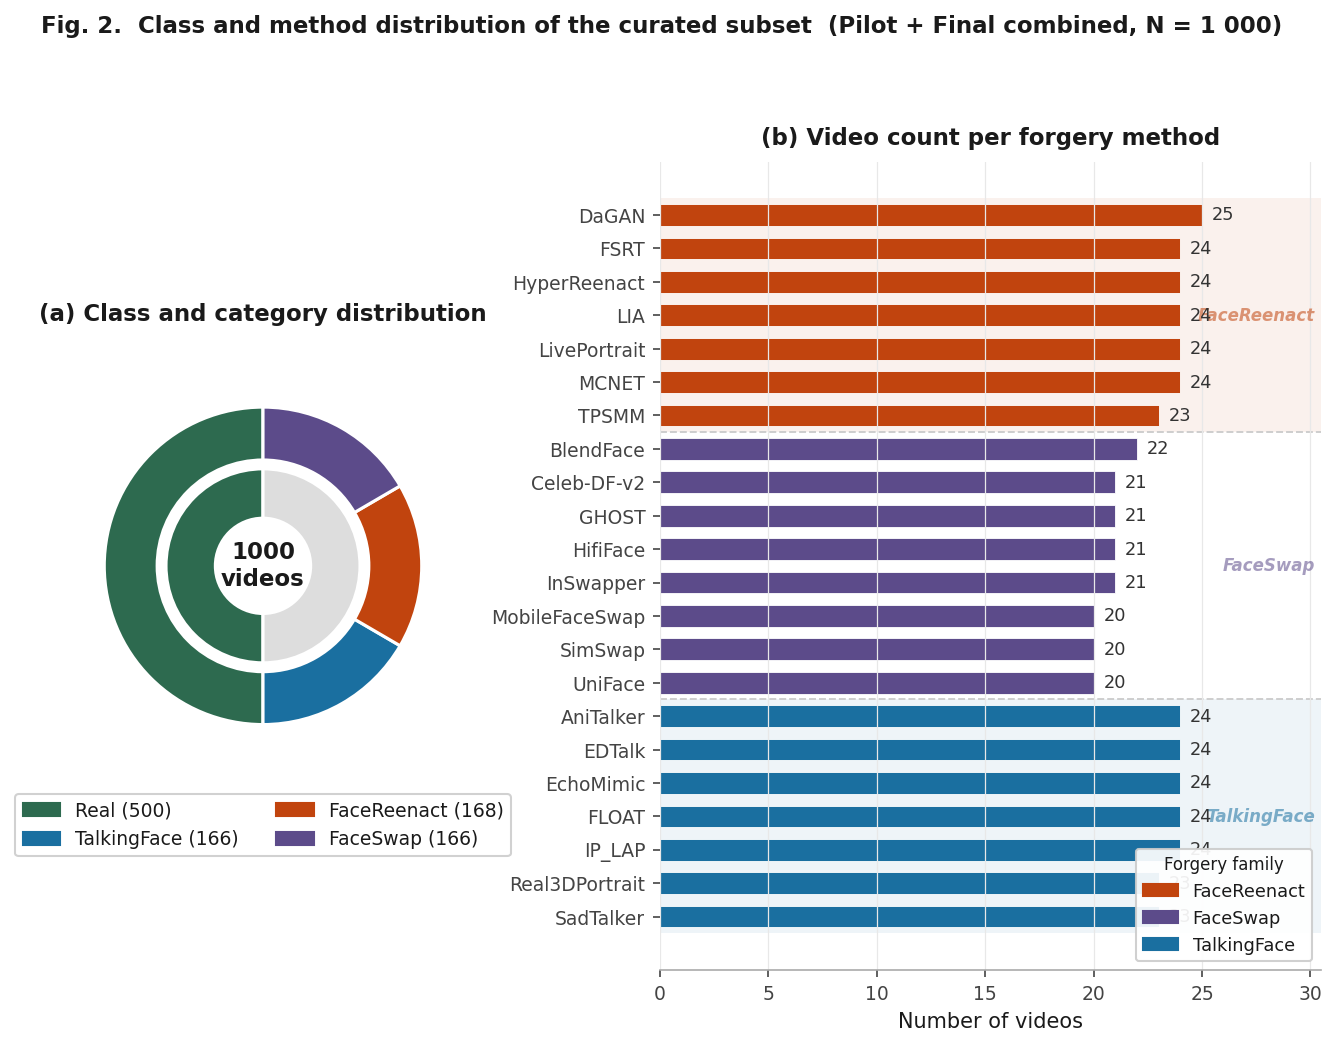

Saved → ../outputs/figures/fig2_combined_distribution.pdf


In [16]:

# ─── Fig. 2 — Combined (Pilot + Final) ─────────────────────────────────────────

n_real_comb = COMBINED_REAL
n_fake_comb = sum(v for fam in COMBINED_FAKE.values() for v in fam.values())

fig = plt.figure(figsize=(11, 7))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1.5], wspace=0.32)

ax_donut = fig.add_subplot(gs[0])
ax_bars = fig.add_subplot(gs[1])

draw_family_donut(
    ax_donut, COMBINED_FAKE, n_real_comb,
    title='(a) Class and category distribution'
)
draw_method_bars(
    ax_bars, combined_df,
    title='(b) Video count per forgery method'
)

fig.suptitle(
    'Class and method distribution of the curated subset',
    fontsize=11, fontweight='bold', y=1.02, ha='center'
)

out = FIGURES_DIR / 'fig2_combined_distribution.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(str(out).replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

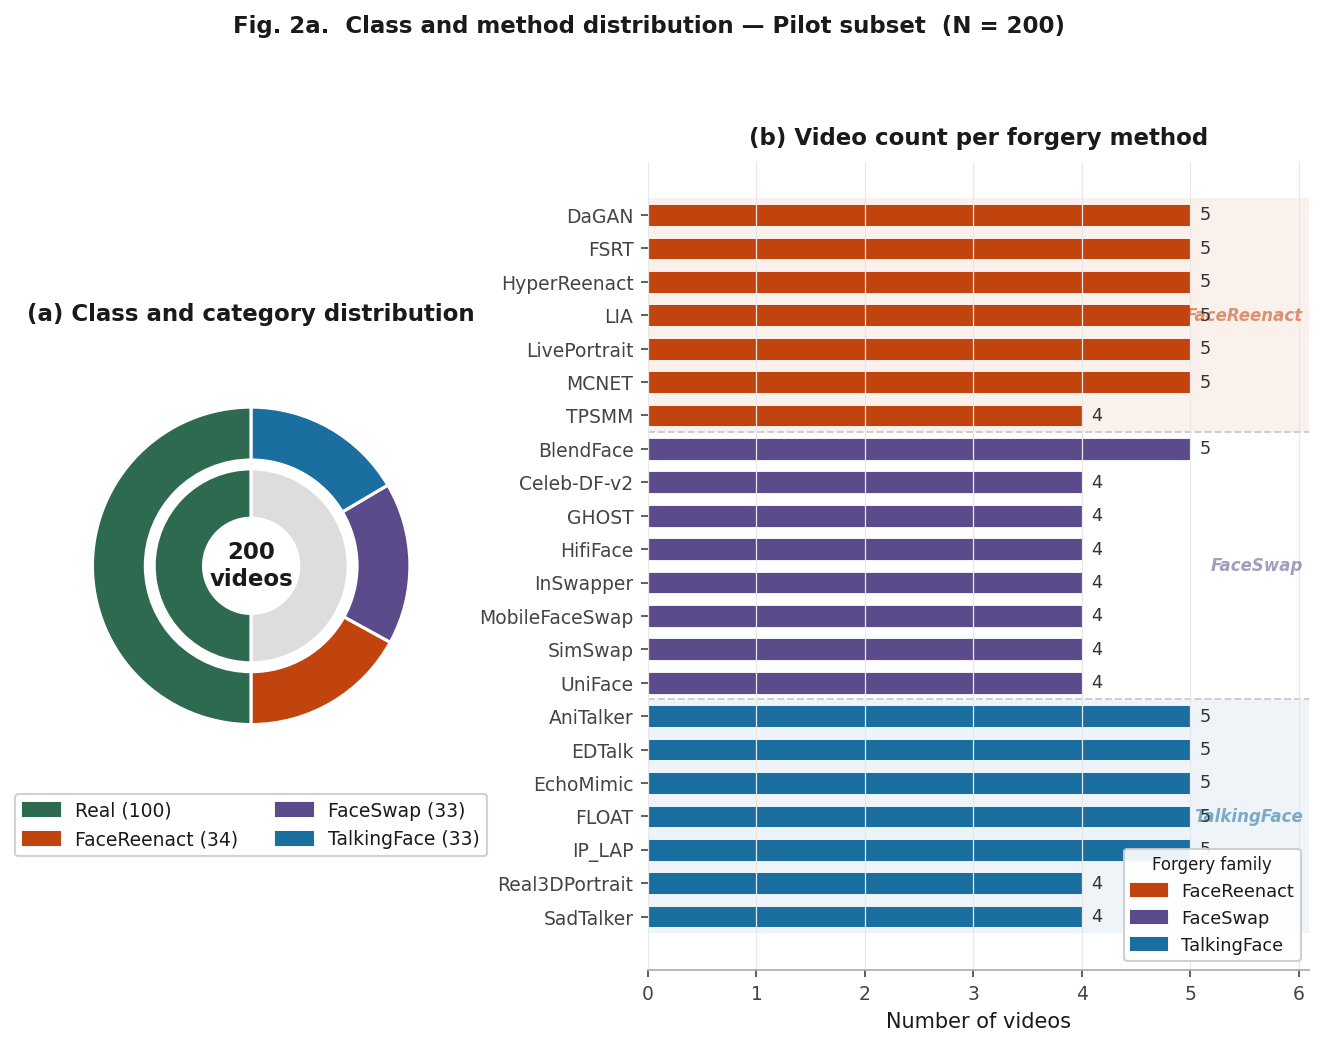

Saved → ../outputs/figures/fig2a_pilot_distribution.pdf


In [17]:

# ─── Fig. 2 — Pilot subset ─────────────────────────────────────────────────────

n_fake_pilot = sum(v for fam in PILOT_FAKE.values() for v in fam.values())

fig = plt.figure(figsize=(11, 7))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1.5], wspace=0.32)

ax_donut = fig.add_subplot(gs[0])
ax_bars = fig.add_subplot(gs[1])

draw_family_donut(
    ax_donut, PILOT_FAKE, PILOT_REAL,
    title='(a) Class and category distribution'
)
draw_method_bars(
    ax_bars, pilot_df,
    title='(b) Video count per forgery method'
)

fig.suptitle(
    f'Fig. 2a.  Class and method distribution — Pilot subset  '
    f'(N = {PILOT_REAL + n_fake_pilot})',
    fontsize=11, fontweight='bold', y=1.02, ha='center'
)

out = FIGURES_DIR / 'fig2a_pilot_distribution.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(str(out).replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

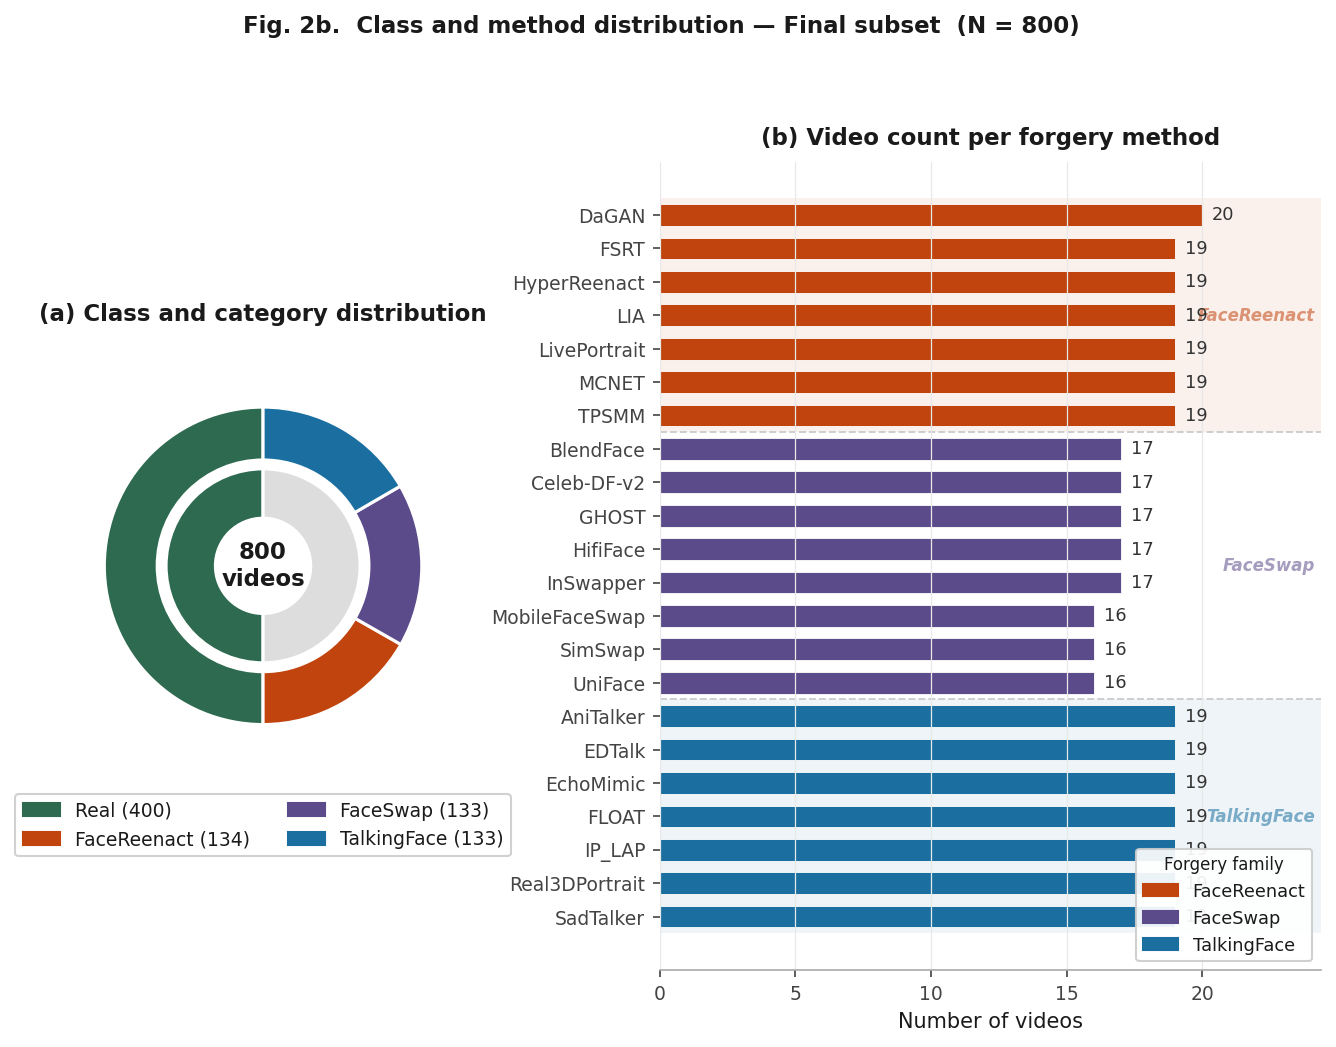

Saved → ../outputs/figures/fig2b_final_distribution.pdf


In [18]:

# ─── Fig. 2 — Final subset ─────────────────────────────────────────────────────

n_fake_final = sum(v for fam in FINAL_FAKE.values() for v in fam.values())

fig = plt.figure(figsize=(11, 7))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1.5], wspace=0.32)

ax_donut = fig.add_subplot(gs[0])
ax_bars = fig.add_subplot(gs[1])

draw_family_donut(
    ax_donut, FINAL_FAKE, FINAL_REAL,
    title='(a) Class and category distribution'
)
draw_method_bars(
    ax_bars, final_df,
    title='(b) Video count per forgery method'
)

fig.suptitle(
    f'Fig. 2b.  Class and method distribution — Final subset  '
    f'(N = {FINAL_REAL + n_fake_final})',
    fontsize=11, fontweight='bold', y=1.02, ha='center'
)

out = FIGURES_DIR / 'fig2b_final_distribution.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(str(out).replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

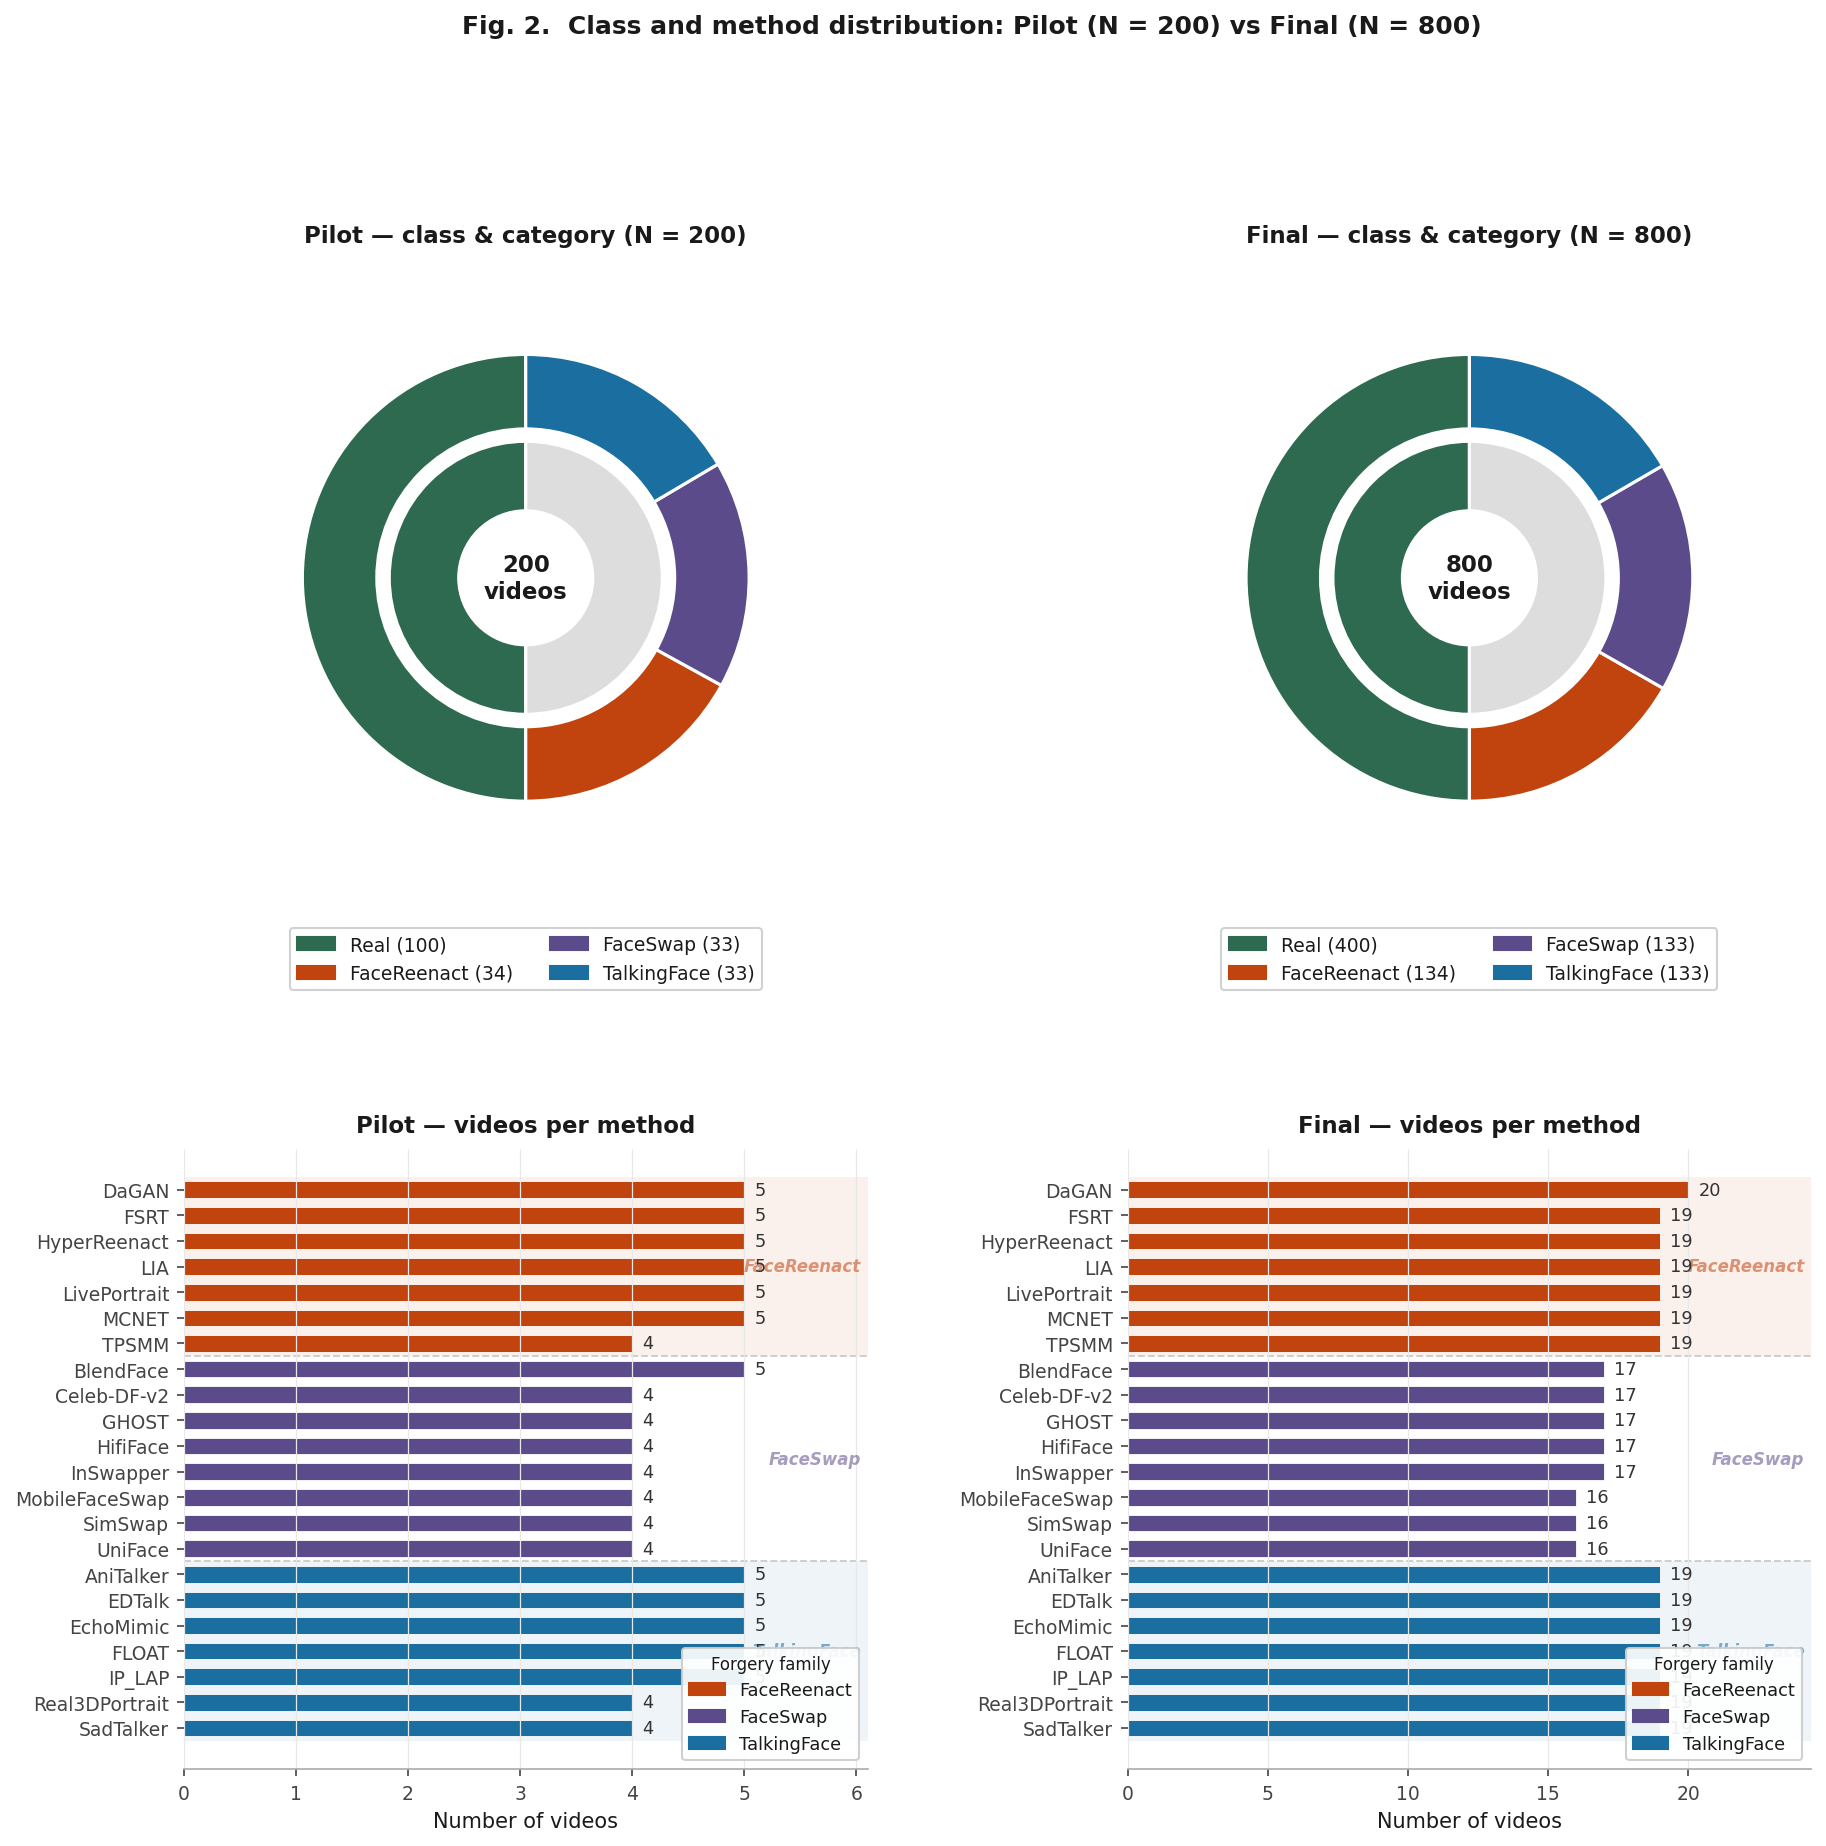

Saved → ../outputs/figures/fig2_pilot_vs_final_comparison.pdf


In [19]:

# ─── Fig. 2 — Side-by-side comparison: Pilot vs Final ──────────────────────────
#
# 2×2 grid: donut row (top) + method-bar row (bottom).

fig = plt.figure(figsize=(14, 13))
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.38, hspace=0.42)

ax_p_donut = fig.add_subplot(gs[0, 0])
ax_f_donut = fig.add_subplot(gs[0, 1])
ax_p_bars = fig.add_subplot(gs[1, 0])
ax_f_bars = fig.add_subplot(gs[1, 1])

draw_family_donut(ax_p_donut, PILOT_FAKE, PILOT_REAL,
                  title='Pilot — class & category (N = 200)')
draw_family_donut(ax_f_donut, FINAL_FAKE, FINAL_REAL,
                  title='Final — class & category (N = 800)')
draw_method_bars(ax_p_bars, pilot_df,
                 title='Pilot — videos per method')
draw_method_bars(ax_f_bars, final_df,
                 title='Final — videos per method')

fig.suptitle(
    'Fig. 2.  Class and method distribution: Pilot (N = 200) vs Final (N = 800)',
    fontsize=12, fontweight='bold', y=1.01, ha='center'
)

out = FIGURES_DIR / 'fig2_pilot_vs_final_comparison.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(str(out).replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

## Figure 3 · Sample Frame Grid

2 rows × 4 columns showing representative frames.  
- **Top row**: real videos (from Celeb-real and YouTube-real sources)  
- **Bottom row**: one fake per forgery family, plus a fourth variant  

The cell below tries to load actual video frames from the manifest CSVs. If the video files are not available on this machine, it falls back to informative placeholder tiles (consistent colour-coded by family).

In [11]:
# ─── Frame extraction utilities ────────────────────────────────────────────────
try:
    import cv2 as _cv2
    CV2_AVAILABLE = True
except (ImportError, RuntimeError):
    _cv2 = None
    CV2_AVAILABLE = False
    print('cv2 not available — placeholder tiles will be used for Fig. 3.')


def _find_project_root(start: Path | None = None) -> Path:
    """Walk upward until we find the thesis project root."""
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'datasets' / 'metadata').exists():
            return candidate
    return start.resolve()


_PROJECT_ROOT = _find_project_root()

MANIFEST_CANDIDATES = [
    _PROJECT_ROOT / 'datasets' / 'metadata' / 'pilot_manifest.csv',
    _PROJECT_ROOT / 'datasets' / 'metadata' / 'final_manifest.csv',
    _PROJECT_ROOT / 'datasets' / 'metadata' / 'pilot_frame_manifest.csv',
    _PROJECT_ROOT / 'datasets' / 'metadata' / 'final_frame_manifest.csv',
    _PROJECT_ROOT / 'datasets' / 'exports' /
    'pilot' / 'csv' / 'pilot_manifest_export.csv',
    _PROJECT_ROOT / 'datasets' / 'exports' /
    'final' / 'csv' / 'final_manifest_export.csv',
]

# Videos live inside the export packages:
# exports/pilot/videos/... and exports/final/videos/...
DATASET_ROOTS = [
    # videos/real/... and videos/fake/...
    _PROJECT_ROOT / 'datasets',
    _PROJECT_ROOT / 'exports' / 'final',
    _PROJECT_ROOT / 'exports' / 'pilot',
    _PROJECT_ROOT,
    Path.home() / 'datasets' / 'extracted' / 'Celeb-DF-v3',
]


def _load_manifest():
    frames = []
    for p in MANIFEST_CANDIDATES:
        if p.exists():
            frames.append(pd.read_csv(p))
    if not frames:
        return None
    return pd.concat(frames, ignore_index=True).drop_duplicates('video_id')


def _resolve_path(raw: str):
    p = Path(raw)
    if p.is_absolute() and p.is_file():
        return p
    for n_strip in range(0, len(p.parts)):
        tail = Path(*p.parts[n_strip:]) if n_strip > 0 else p
        for root in DATASET_ROOTS:
            candidate = root / tail
            if candidate.is_file():
                return candidate
    return None


def extract_frame(video_path: str, frame_idx: int = None):
    if not CV2_AVAILABLE:
        return None
    resolved = _resolve_path(str(video_path))
    if resolved is None:
        return None
    cap = _cv2.VideoCapture(str(resolved))
    if not cap.isOpened():
        return None
    n_frames = int(cap.get(_cv2.CAP_PROP_FRAME_COUNT))
    if frame_idx is None:
        frame_idx = max(1, n_frames // 3)
    cap.set(_cv2.CAP_PROP_POS_FRAMES, min(frame_idx, n_frames - 1))
    ok, frame = cap.read()
    cap.release()
    return _cv2.cvtColor(frame, _cv2.COLOR_BGR2RGB) if ok else None


def _placeholder_tile(label: str, subtitle: str, family, size=(224, 224)):
    h, w = size
    if family and family in FAMILY_COLORS:
        r, g, b, _ = to_rgba(FAMILY_COLORS[family])
    elif label == 'real':
        r, g, b, _ = to_rgba(REAL_COLOR)
    else:
        r, g, b = 0.45, 0.45, 0.45
    bg = np.full((h, w, 3),
                 [int(r * 160 + 95), int(g * 160 + 95), int(b * 160 + 95)],
                 dtype=np.uint8)
    fig_tmp, ax_tmp = plt.subplots(figsize=(w / 100, h / 100), dpi=100)
    ax_tmp.imshow(bg)
    ax_tmp.text(0.5, 0.55, subtitle, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white',
                transform=ax_tmp.transAxes, multialignment='center')
    ax_tmp.text(0.5, 0.28, label.upper(), ha='center', va='center',
                fontsize=7, color='white', alpha=0.8,
                transform=ax_tmp.transAxes, style='italic')
    ax_tmp.axis('off')
    fig_tmp.subplots_adjust(0, 0, 1, 1)
    fig_tmp.canvas.draw()
    buf = np.frombuffer(fig_tmp.canvas.tostring_rgb(), dtype=np.uint8)
    buf = buf.reshape(fig_tmp.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig_tmp)
    from PIL import Image as _PIL
    return np.array(_PIL.fromarray(buf).resize((w, h), _PIL.LANCZOS))


print(f'Frame utilities loaded  |  cv2: {CV2_AVAILABLE}')
print(f'Project root: {_PROJECT_ROOT}')
print(f'Manifest files exist:  '
      f'pilot_manifest={(_PROJECT_ROOT/"datasets/metadata/pilot_face_manifest.csv").exists()}  '
      f'final_manifest={(_PROJECT_ROOT/"datasets/metadata/final_face_manifest.csv").exists()}  '
      f'pilot_frame={(_PROJECT_ROOT/"datasets/metadata/pilot_frame_manifest.csv").exists()}  '
      f'final_frame={(_PROJECT_ROOT/"datasets/metadata/final_frame_manifest.csv").exists()}')

Frame utilities loaded  |  cv2: True
Project root: /home/n.salikhova@innopolis.university/deepfake-emotion-robustness
Manifest files exist:  pilot_manifest=True  final_manifest=True  pilot_frame=True  final_frame=True


Manifest loaded: 800 rows


AttributeError: 'FigureCanvasAgg' object has no attribute 'tostring_rgb'

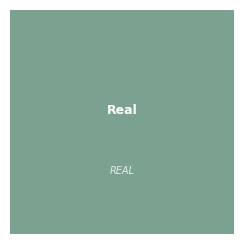

In [12]:

# ─── Fig. 3 — Sample frame grid ───────────────────────────────────────────────
# Layout: 2 rows × 4 columns
# Row 0 (top):    4 real frames  (Celeb-real / YouTube-real sources)
# Row 1 (bottom): 4 fake frames  — one per forgery family + one extra variant

GRID_SPEC = [
    # (label, family, method, subtitle)
    ('real', None,          None,           'Real'),
    ('real', None,          None,           'Real'),
    ('real', None,          None,           'Real'),
    ('real', None,          None,           'Real'),
    ('fake', 'FaceReenact', 'DaGAN',        'FaceReenact\n(DaGAN)'),
    ('fake', 'FaceSwap',    'BlendFace',    'FaceSwap\n(BlendFace)'),
    ('fake', 'TalkingFace', 'EchoMimic',    'TalkingFace\n(EchoMimic)'),
    ('fake', 'FaceSwap',    'HifiFace',     'FaceSwap\n(HifiFace)'),
]


def _pick_video(manifest, label, family, method, used_ids, seed_offset=0):
    if manifest is None:
        return None, seed_offset
    mask = manifest['label'] == label
    if family:
        mask &= manifest['manipulation_family'] == family
    if method:
        mask &= manifest['manipulation_type'] == method
    mask &= ~manifest['video_id'].isin(used_ids)
    pool = manifest[mask]
    if pool.empty:
        return None, seed_offset
    return pool.sample(1, random_state=42 + seed_offset).iloc[0], seed_offset + 1


manifest = _load_manifest()
print(f'Manifest loaded: {len(manifest)} rows' if manifest is not None
      else 'Manifest not found — placeholder tiles will be used.')

frames_data = []   # list of (rgb_array, subtitle, label, family)
used_ids = set()
seed_ctr = 0

for label, family, method, subtitle in GRID_SPEC:
    frame = None
    row_meta, seed_ctr = _pick_video(
        manifest, label, family, method, used_ids, seed_ctr)

    if row_meta is not None:
        used_ids.add(row_meta['video_id'])
        frame = extract_frame(row_meta.get('path', ''))
        if frame is not None:
            # Centre-crop to square then resize — uses _cv2 (the aliased import)
            h, w = frame.shape[:2]
            s = min(h, w)
            y0, x0 = (h - s) // 2, (w - s) // 2
            frame = frame[y0:y0 + s, x0:x0 + s]
            frame = _cv2.resize(frame, (224, 224),
                                interpolation=_cv2.INTER_AREA)

    if frame is None:
        frame = _placeholder_tile(label, subtitle, family)

    frames_data.append((frame, subtitle, label, family))

# ── Draw the grid ──────────────────────────────────────────────────────────────
N_COLS, N_ROWS = 4, 2

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * 2.6, N_ROWS * 2.9),
    gridspec_kw={'hspace': 0.30, 'wspace': 0.08},
)

for idx, (frame, subtitle, label, family) in enumerate(frames_data):
    r, c = divmod(idx, N_COLS)
    ax = axes[r, c]
    ax.imshow(frame, interpolation='bilinear')
    ax.axis('off')

    col = FAMILY_COLORS.get(
        family, REAL_COLOR) if label == 'fake' else REAL_COLOR
    ax.set_xlabel(subtitle, fontsize=8, labelpad=4,
                  color=col, fontweight='bold')
    ax.xaxis.set_label_position('bottom')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(col)
        spine.set_linewidth(2.5)

# Row labels on the left
for r_idx, (row_label, row_color) in enumerate(
        zip(['Real', 'Fake'], [REAL_COLOR, FAKE_COLOR])):
    axes[r_idx, 0].annotate(
        row_label,
        xy=(0, 0.5), xycoords='axes fraction',
        xytext=(-18, 0), textcoords='offset points',
        ha='right', va='center',
        fontsize=10, fontweight='bold', color=row_color, rotation=90,
    )

fig.suptitle(
    'Fig. 3.  Sample frames from the curated subset\n'
    '(top row: real; bottom row: fake — one per forgery type)',
    fontsize=10.5, fontweight='bold', y=1.03, ha='center',
)
fig.text(0.5, -0.01,
         'Source: Celeb-DF-v3. '
         + ('Actual video frames shown.' if CV2_AVAILABLE
            else 'Placeholder tiles — cv2 unavailable (NumPy ABI mismatch; '
                 'fix: pip install --upgrade opencv-python-headless>=4.9.0).'),
         ha='center', fontsize=7.5, color='#777777', style='italic')

out = FIGURES_DIR / 'fig3_sample_frames.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(str(out).replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')
print(f'Real frames extracted: {CV2_AVAILABLE}')

In [ ]:
# ─── Summary of saved files ────────────────────────────────────────────────────
print('Saved figures:')
for f in sorted(FIGURES_DIR.glob('fig*.*')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<50s}  {size_kb:>7.1f} KB')

Saved figures:
  fig2_combined_distribution.pdf                         39.5 KB
  fig2_combined_distribution.png                        330.7 KB
  fig2_pilot_vs_final_comparison.pdf                     42.9 KB
  fig2_pilot_vs_final_comparison.png                    468.2 KB
  fig2a_pilot_distribution.pdf                           38.6 KB
  fig2a_pilot_distribution.png                          310.5 KB
  fig2b_final_distribution.pdf                           39.4 KB
  fig2b_final_distribution.png                          322.0 KB
  fig3_sample_frames.pdf                                126.1 KB
  fig3_sample_frames.png                                147.1 KB



## Figure 4 · Face Detection and Alignment Pipeline

Three-panel illustration of the preprocessing pipeline for one **real** and one **fake** example:

| Panel | Content |
|-------|---------|
| **(a)** | Original decoded video frame |
| **(b)** | RetinaFace / MediaPipe detection — bounding box + landmarks overlay |
| **(c)** | Aligned and cropped face (112 × 112 px, margin 20 %) |

> **Note:** The cell below first tries to run MediaPipe face detection inline.
> If the detection library is not yet installed, it falls back to a labelled
> placeholder layout so the figure structure is preserved for the thesis draft.
> Replace the placeholders with your actual pipeline outputs once
> `scripts/extract_faces.py` is fully implemented.


In [ ]:

# ─── Face pipeline utilities ───────────────────────────────────────────────────
# The pipeline (face-preprocessing copy.ipynb) already ran InsightFace buffalo_l
# and saved outputs to datasets/processed/final/.
# We load those manifests directly — no detection needed here.

FACE_MANIFEST_PATH  = _PROJECT_ROOT / 'datasets' / 'metadata' / 'final_face_manifest.csv'
FRAME_MANIFEST_PATH = _PROJECT_ROOT / 'datasets' / 'metadata' / 'final_frame_manifest.csv'

def _load_face_manifest():
    if FACE_MANIFEST_PATH.exists():
        return pd.read_csv(FACE_MANIFEST_PATH)
    return None

face_manifest_full = _load_face_manifest()

if face_manifest_full is not None:
    print(f'Face manifest loaded: {len(face_manifest_full):,} rows')
    print(f'  real: {(face_manifest_full["label"]=="real").sum():,}  '
          f'fake: {(face_manifest_full["label"]=="fake").sum():,}')
else:
    print(f'Face manifest not found at:\n  {FACE_MANIFEST_PATH}')
    print('Run face-preprocessing copy.ipynb first.')


def _load_img_rgb(path_str: str):
    """Load a JPEG/PNG as RGB uint8 array via cv2."""
    if not CV2_AVAILABLE:
        return None
    p = Path(path_str)
    if not p.exists():
        return None
    bgr = _cv2.imread(str(p))
    if bgr is None:
        return None
    return _cv2.cvtColor(bgr, _cv2.COLOR_BGR2RGB)


def draw_insightface_bbox(rgb: np.ndarray, x1, y1, x2, y2,
                          color=(0, 220, 100), thickness=3) -> np.ndarray:
    """Draw a single bounding box (InsightFace bbox coords) on an RGB image."""
    img = rgb.copy()
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    # Draw thick rectangle via slice assignment (avoids cv2 dependency for line drawing)
    h, w = img.shape[:2]
    t = thickness
    img[max(0,y1):y1+t,       max(0,x1):min(w,x2)] = color  # top
    img[max(0,y2-t):min(h,y2), max(0,x1):min(w,x2)] = color  # bottom
    img[max(0,y1):min(h,y2),  max(0,x1):x1+t]       = color  # left
    img[max(0,y1):min(h,y2),  max(0,x2-t):min(w,x2)] = color # right
    return img


print('Face pipeline utilities ready.')


Face manifest loaded: 47,022 rows
  real: 27,753  fake: 19,269
Face pipeline utilities ready.


Real: video=YouTube-real__00117__bdf249b7...
       frame_path exists: True
       face_path  exists: True
Fake: video=Celeb-synthesis__FaceSwap__BlendFace__id6_id0_0001...
       frame_path exists: True
       face_path  exists: True


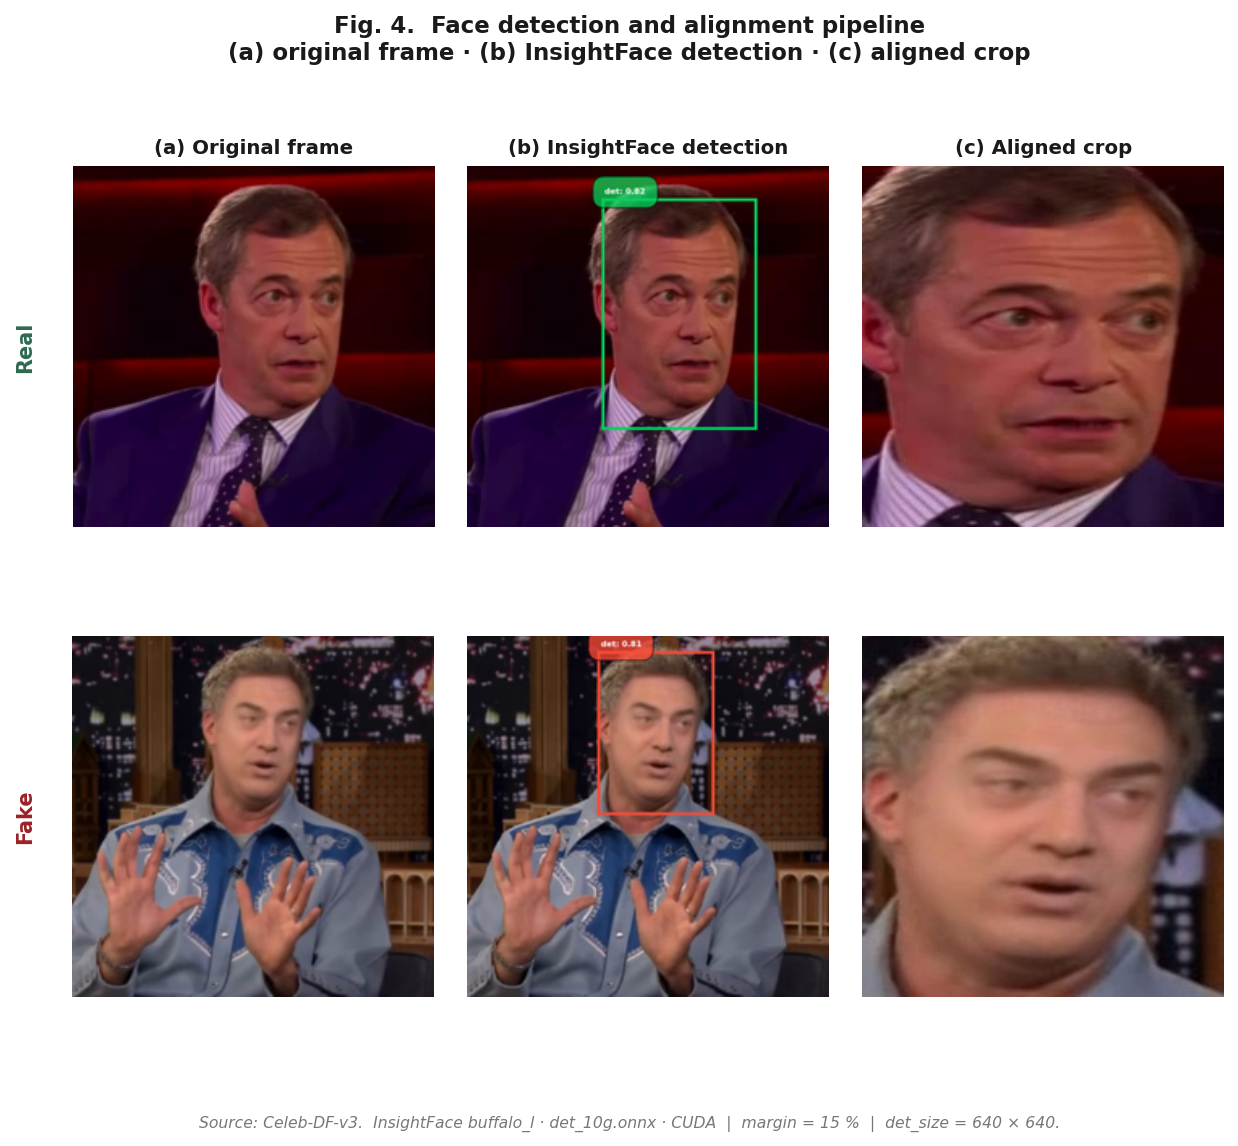

Saved → ../outputs/figures/fig4_face_detection_pipeline.pdf


In [ ]:

# ─── Fig. 4 — Face detection and alignment pipeline ───────────────────────────
# Loads pre-computed InsightFace (buffalo_l) results from face_manifest.csv.
# Three panels per example row:
#   (a) original decoded frame
#   (b) InsightFace bbox overlay
#   (c) aligned & cropped face (saved by face-preprocessing copy.ipynb)

TILE = 224   # px per panel

def _pick_face_row(label, family=None, method=None, seed=77):
    """Sample one row from the face manifest matching label/family/method."""
    if face_manifest_full is None:
        return None
    mask = face_manifest_full['label'] == label
    if family:
        mask &= face_manifest_full['manipulation_family'] == family
    if method:
        mask &= face_manifest_full['manipulation_type'] == method
    pool = face_manifest_full[mask]
    if pool.empty:
        return None
    return pool.sample(1, random_state=seed).iloc[0]

real_row = _pick_face_row('real', seed=77)
fake_row = _pick_face_row('fake', family='FaceSwap', method='BlendFace', seed=13)

for name, row in [('Real', real_row), ('Fake', fake_row)]:
    if row is not None:
        print(f'{name}: video={row["video_id"][:50]}...')
        print(f'       frame_path exists: {Path(row["frame_path"]).exists()}')
        print(f'       face_path  exists: {Path(row["face_path"]).exists()}')
    else:
        print(f'{name}: no matching row found')


def _build_triplet_from_manifest(row, label: str):
    """Build (panel_a, panel_b, panel_c) from face manifest row."""
    row_color = REAL_COLOR if label == 'real' else FAMILY_COLORS.get(
        row.get('manipulation_family') if row is not None else None, FAKE_COLOR)

    if row is None or not CV2_AVAILABLE:
        return (
            _placeholder_panel(f'{label.capitalize()} frame',
                               'original video frame', row_color),
            _placeholder_panel('Detection overlay',
                               'InsightFace (buffalo_l)\nbbox', row_color),
            _placeholder_panel('Aligned crop',
                               'face with 15 % margin', row_color),
        )

    # ── Panel (a): original frame ─────────────────────────────────────────────
    orig = _load_img_rgb(row['frame_path'])
    if orig is None:
        pa = _placeholder_panel(f'{label.capitalize()} frame',
                                'frame file missing', row_color)
    else:
        h, w = orig.shape[:2]
        s = min(h, w); y0, x0 = (h-s)//2, (w-s)//2
        pa = _cv2.resize(orig[y0:y0+s, x0:x0+s], (TILE, TILE),
                         interpolation=_cv2.INTER_AREA)

    # ── Panel (b): bbox overlay ───────────────────────────────────────────────
    if orig is None:
        pb = _placeholder_panel('Detection overlay',
                                'InsightFace (buffalo_l)\nbbox', row_color)
    else:
        bbox_color = (0, 210, 90) if label == 'real' else (255, 75, 55)
        overlay = draw_insightface_bbox(
            orig,
            row['bbox_x1'], row['bbox_y1'],
            row['bbox_x2'], row['bbox_y2'],
            color=bbox_color, thickness=4,
        )
        # Score annotation
        score_txt = f'det: {float(row["det_score"]):.2f}'
        # Use matplotlib text overlay (no cv2.putText needed)
        fig_ov, ax_ov = plt.subplots(figsize=(orig.shape[1]/100, orig.shape[0]/100), dpi=100)
        ax_ov.imshow(overlay)
        ax_ov.text(row['bbox_x1'] + 4, max(row['bbox_y1'] - 6, 12),
                   score_txt, color='white', fontsize=8, fontweight='bold',
                   bbox=dict(facecolor=tuple(c/255 for c in bbox_color),
                             alpha=0.75, pad=1.5, boxstyle='round'))
        ax_ov.axis('off')
        fig_ov.subplots_adjust(0, 0, 1, 1)
        fig_ov.canvas.draw()
        buf = np.frombuffer(fig_ov.canvas.tostring_rgb(), dtype=np.uint8)
        buf = buf.reshape(fig_ov.canvas.get_width_height()[::-1] + (3,))
        plt.close(fig_ov)
        from PIL import Image as _PIL
        h, w = orig.shape[:2]; s = min(h,w); y0,x0=(h-s)//2,(w-s)//2
        pb = np.array(_PIL.fromarray(buf[y0:y0+s, x0:x0+s]).resize((TILE,TILE), _PIL.LANCZOS))

    # ── Panel (c): aligned crop ───────────────────────────────────────────────
    crop = _load_img_rgb(row['face_path'])
    if crop is None:
        pc = _placeholder_panel('Aligned crop',
                                'face file missing', row_color)
    else:
        from PIL import Image as _PIL
        pc = np.array(_PIL.fromarray(crop).resize((TILE, TILE), _PIL.LANCZOS))

    return pa, pb, pc


real_a, real_b, real_c = _build_triplet_from_manifest(real_row, 'real')
fake_a, fake_b, fake_c = _build_triplet_from_manifest(
    fake_row, 'fake')

# ── Draw figure ───────────────────────────────────────────────────────────────
COL_TITLES = ['(a) Original frame', '(b) InsightFace detection', '(c) Aligned crop']
ROWS = [
    ('Real', real_a, real_b, real_c, REAL_COLOR),
    ('Fake', fake_a, fake_b, fake_c, FAKE_COLOR),
]

fig, axes = plt.subplots(2, 3, figsize=(10, 7.2),
                         gridspec_kw={'hspace': 0.30, 'wspace': 0.06})

for r_idx, (row_label, pa, pb, pc, row_color) in enumerate(ROWS):
    for c_idx, (panel, ctitle) in enumerate(zip([pa, pb, pc], COL_TITLES)):
        ax = axes[r_idx, c_idx]
        ax.imshow(panel, interpolation='bilinear')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(row_color)
            spine.set_linewidth(2.2)
        if r_idx == 0:
            ax.set_title(ctitle, fontsize=9.5, fontweight='bold', pad=6)

    axes[r_idx, 0].annotate(
        row_label, xy=(0, 0.5), xycoords='axes fraction',
        xytext=(-18, 0), textcoords='offset points',
        ha='right', va='center',
        fontsize=10, fontweight='bold', color=row_color, rotation=90,
    )

pipeline_note = ('InsightFace buffalo_l · det_10g.onnx · CUDA  |  margin = 15 %  |  '
                 'det_size = 640 × 640'
                 if face_manifest_full is not None else
                 'Face manifest not found — run face-preprocessing copy.ipynb first')

fig.suptitle(
    'Fig. 4.  Face detection and alignment pipeline\n'
    '(a) original frame · (b) InsightFace detection · (c) aligned crop',
    fontsize=11, fontweight='bold', y=1.02, ha='center',
)
fig.text(0.5, -0.01, f'Source: Celeb-DF-v3.  {pipeline_note}.',
         ha='center', fontsize=7.5, color='#777777', style='italic')

out = FIGURES_DIR / 'fig4_face_detection_pipeline.pdf'
fig.savefig(out, bbox_inches='tight')
fig.savefig(str(out).replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')



## Figure 5 · Frame-level Emotion Annotation

Two-panel figure for one representative video:

| Panel | Content |
|-------|---------|
| **(a)** | Valence and arousal over time (line plot) |
| **(b)** | Per-category emotion score heatmap — rows = emotion categories, columns = sampled frames |

> **TODO:** Replace synthetic demo data with real EmoNet/EmoNet-Face predictions once
> `scripts/annotate_emotions.py` has run and produced an emotion manifest CSV.
> Expected schema: `video_id, frame_id, timestamp_sec, valence, arousal, neutral,
> happiness, surprise, fear, disgust, anger, contempt, sadness` (8-class EmoNet)
> or 40 columns for the full EmoNet-Face model.


In [ ]:

# ─── Fig. 5 — Frame-level emotion annotation ──────────────────────────────────
import seaborn as sns

# ── 1. Load emotion manifest ──────────────────────────────────────────────────
EMOTION_MANIFEST_CANDIDATES = [
    _PROJECT_ROOT / 'datasets' / 'emotion_annotated' / 'metadata' / 'final_frame_emotion_predictions.csv',
    _PROJECT_ROOT / 'datasets' / 'emotion_annotated' / 'metadata' / 'pilot_frame_emotion_predictions.csv',
]

NON_EMO_COLS = {'video_id','frame_id','face_id','face_path','timestamp_sec',
                'label','split','manipulation_family','manipulation_type',
                'identity','source_subset','frame_path','pred_emotion',
                'pred_emotion_score','valence','arousal'}

emotion_df_full = None
for p in EMOTION_MANIFEST_CANDIDATES:
    if p.exists():
        emotion_df_full = pd.read_csv(p)
        print(f'Loaded: {p.name}  ({len(emotion_df_full):,} rows)')
        break

if emotion_df_full is None:
    print('Emotion manifest not found — using synthetic demo data.')

# ── 2. Select / simulate one representative video ─────────────────────────────
rng = np.random.default_rng(42)

if emotion_df_full is not None:
    # Pick the fake video with the most annotated frames
    rep_video_id = emotion_df_full.groupby('video_id').size().idxmax()
    video_df = (emotion_df_full[emotion_df_full['video_id'] == rep_video_id]
                .sort_values('timestamp_sec').reset_index(drop=True))

    # Detect score_* columns and cast to float
    emo_cols = [c for c in video_df.columns
                if c.startswith('score_') or (c not in NON_EMO_COLS and c not in
                   {'video_id','frame_id','face_id','face_path','timestamp_sec',
                    'label','split','manipulation_family','manipulation_type',
                    'pred_emotion','pred_emotion_score','valence','arousal'})]
    # Convert to numeric, coerce strings/NaN
    video_df[emo_cols] = video_df[emo_cols].apply(pd.to_numeric, errors='coerce')
    # Drop columns that are entirely NaN
    emo_cols = [c for c in emo_cols if video_df[c].notna().any()]

    # Clean display names: strip 'score_' prefix, replace underscores, title-case
    def _clean_label(col: str) -> str:
        name = col.removeprefix('score_').replace('_', ' ')
        return name[:28]   # cap length for heatmap y-axis

    label_tag  = video_df['label'].iloc[0] if 'label' in video_df else 'unknown'
    method_tag = (video_df['manipulation_type'].iloc[0]
                  if 'manipulation_type' in video_df.columns else '')
    timestamps   = video_df['timestamp_sec'].to_numpy(dtype=float)
    valence      = pd.to_numeric(video_df['valence'], errors='coerce').to_numpy(dtype=float)
    arousal      = pd.to_numeric(video_df['arousal'], errors='coerce').to_numpy(dtype=float)
    heatmap_data = video_df[emo_cols].to_numpy(dtype=float).T  # (n_emotions, n_frames)
    display_labels = [_clean_label(c) for c in emo_cols]

else:
    # Synthetic demo — 10-second fake, 8 basic emotions
    N = 50
    timestamps = np.linspace(0, 10, N)
    t = np.linspace(0, 2 * np.pi, N)
    valence = np.clip(0.25 * np.sin(t) + 0.10 * rng.standard_normal(N), -1, 1)
    arousal = np.clip(0.35 + 0.20 * np.cos(t * 0.7) + 0.08 * rng.standard_normal(N), 0, 1)
    raw = rng.exponential(scale=[3.0, 1.8, 0.6, 0.3, 0.2, 0.3, 0.2, 0.5], size=(N, 8))
    for i in range(8):
        raw[:, i] += 0.4 * np.abs(np.sin(t * (i * 0.3 + 0.5)))
    raw /= raw.sum(axis=1, keepdims=True)
    heatmap_data   = raw.T
    emo_cols       = ['neutral','happiness','surprise','fear',
                      'disgust','anger','contempt','sadness']
    display_labels = [e.capitalize() for e in emo_cols]
    label_tag, method_tag, rep_video_id = 'fake', 'BlendFace (demo)', 'demo_video'

# ── 3. Subsample to ≤ 30 columns for a readable heatmap ──────────────────────
MAX_COLS = 30
n_frames = heatmap_data.shape[1]
if n_frames > MAX_COLS:
    idx = np.linspace(0, n_frames - 1, MAX_COLS, dtype=int)
    heatmap_data    = heatmap_data[:, idx]
    timestamps_heat = timestamps[idx]
else:
    timestamps_heat = timestamps.copy()


Loaded: final_frame_emotion_predictions.csv  (47,022 rows)


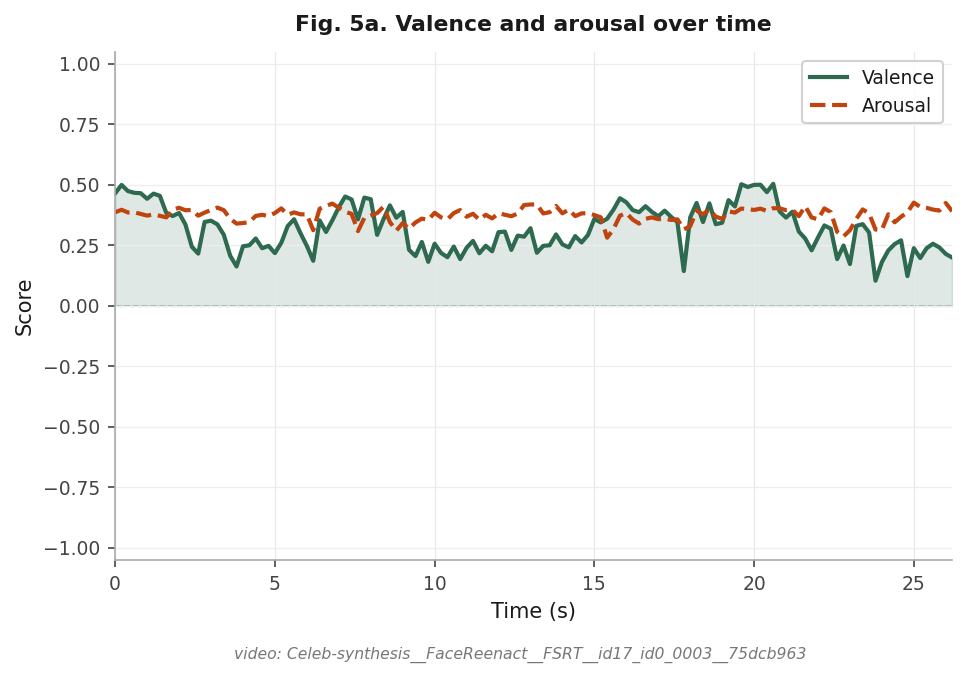

Saved → ../outputs/figures/fig5a_valence_arousal.pdf


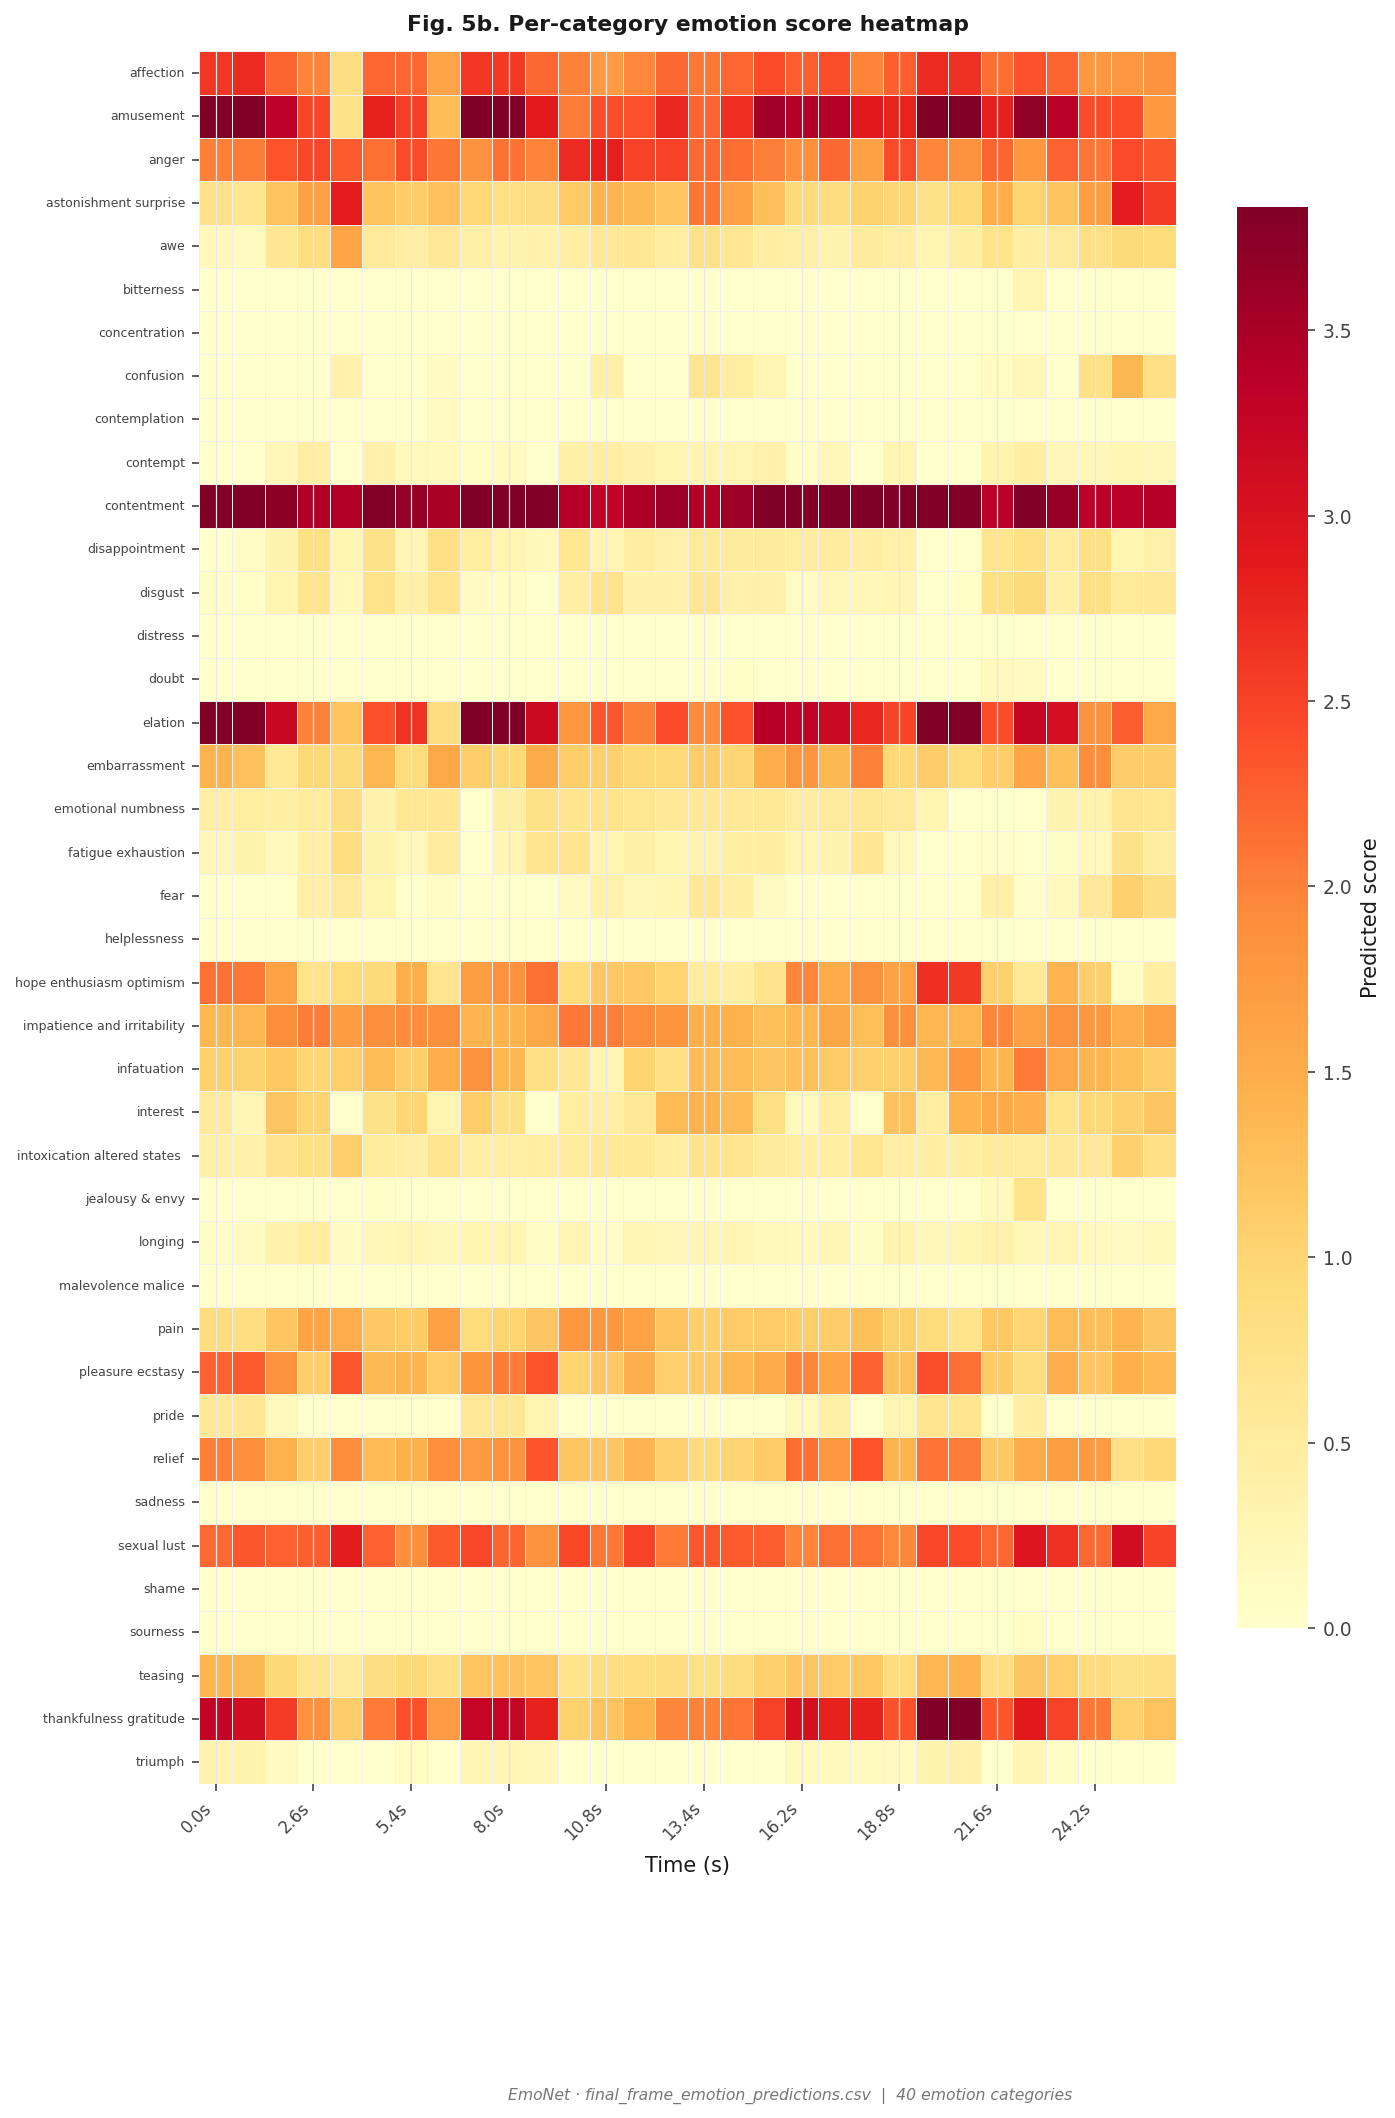

Saved → ../outputs/figures/fig5b_emotion_heatmap.pdf
Mode: real  |  frames: 30  |  emotion classes: 40


In [ ]:
# ── 4. Draw separate figures ─────────────────────────────────────────────────

# ===== Figure 5a — valence / arousal =====
fig_line, ax_line = plt.subplots(figsize=(7.2, 4.4))

ax_line.axhline(0, color='#CCCCCC', linewidth=0.8, linestyle='--', zorder=0)
ax_line.fill_between(
    timestamps, np.nan_to_num(valence), 0,
    where=(np.nan_to_num(valence) >= 0),
    alpha=0.15, color='#2D6A4F', interpolate=True
)
ax_line.fill_between(
    timestamps, np.nan_to_num(valence), 0,
    where=(np.nan_to_num(valence) < 0),
    alpha=0.15, color='#9B2226', interpolate=True
)
ax_line.plot(timestamps, valence, color='#2D6A4F', linewidth=2.0, label='Valence')
ax_line.plot(
    timestamps, arousal,
    color='#C1440E', linewidth=2.0, linestyle='--', label='Arousal'
)

ax_line.set_xlabel('Time (s)', fontsize=10)
ax_line.set_ylabel('Score', fontsize=10)
ax_line.set_ylim(-1.05, 1.05)
ax_line.set_xlim(timestamps[0], timestamps[-1])
ax_line.legend(fontsize=9, framealpha=0.9)
ax_line.set_title('Fig. 5a. Valence and arousal over time',
                  fontsize=10.5, fontweight='bold', pad=10)
ax_line.grid(True, axis='y', color='#EEEEEE', linewidth=0.6)
ax_line.spines['top'].set_visible(False)
ax_line.spines['right'].set_visible(False)

fig_line.text(
    0.5, -0.04,
    f'video: {str(rep_video_id)[:60] + ("…" if len(str(rep_video_id)) > 60 else "")}',
    ha='center', fontsize=7.5, color='#777777', style='italic',
)

out_line_pdf = FIGURES_DIR / 'fig5a_valence_arousal.pdf'
out_line_png = FIGURES_DIR / 'fig5a_valence_arousal.png'
fig_line.savefig(out_line_pdf, bbox_inches='tight')
fig_line.savefig(out_line_png, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out_line_pdf}')


# ===== Figure 5b — heatmap =====
fig_heat_h = max(5.8, len(display_labels) * 0.32 + 2.2)
fig_heat, ax_heat = plt.subplots(figsize=(10.5, fig_heat_h))

n_cols = heatmap_data.shape[1]
tick_every = max(1, n_cols // 8)
xtick_lab = [f'{timestamps_heat[i]:.1f}s' for i in range(0, n_cols, tick_every)]

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=display_labels,
    columns=[f'{tt:.1f}' for tt in timestamps_heat],
)

vmax_val = (
    float(np.nanpercentile(heatmap_data[np.isfinite(heatmap_data)], 98))
    if np.isfinite(heatmap_data).any() else 1.0
)

sns.heatmap(
    heatmap_df,
    ax=ax_heat,
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax_val,
    linewidths=0.3,
    linecolor='#F0F0F0',
    cbar_kws={'label': 'Predicted score', 'shrink': 0.82},
    xticklabels=tick_every,
)

ax_heat.set_xticklabels(xtick_lab, rotation=45, ha='right', fontsize=8)
ax_heat.set_yticklabels(
    ax_heat.get_yticklabels(),
    rotation=0,
    fontsize=max(6, 9 - len(display_labels) // 10)
)
ax_heat.set_xlabel('Time (s)', fontsize=10, labelpad=6)
ax_heat.set_ylabel('')
ax_heat.set_title('Fig. 5b. Per-category emotion score heatmap',
                  fontsize=10.5, fontweight='bold', pad=10)

fig_heat.text(
    0.5, -0.03,
    (f'EmoNet · final_frame_emotion_predictions.csv  |  {len(emo_cols)} emotion categories'
     if emotion_df_full is not None else
     'Synthetic preview — replace once final_frame_emotion_predictions.csv is present'),
    ha='center', fontsize=7.5, color='#777777', style='italic',
)

out_heat_pdf = FIGURES_DIR / 'fig5b_emotion_heatmap.pdf'
out_heat_png = FIGURES_DIR / 'fig5b_emotion_heatmap.png'
fig_heat.savefig(out_heat_pdf, bbox_inches='tight')
fig_heat.savefig(out_heat_png, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out_heat_pdf}')


print(
    f'Mode: {"real" if emotion_df_full is not None else "demo"}  |  '
    f'frames: {n_cols}  |  emotion classes: {len(emo_cols)}'
)